# Previously made first MLP of makemore, now want to make more complex neural networks such as a recural neural network

## before that we want to focus more on malalia perception to understand activations and gradients better

#### recural nerual networks are a lot harder to optimize which leads to spin offs of those

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [2]:
words = open('names.txt','r').read().splitlines()

To start, lets take the previous lesson and make the code less messy

In [3]:
# build the vocab of chars and mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build dataset
block_size = 3 # context length: how many chars do we take to predict the next one

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1]) #80
Xdev, Ydev = build_dataset(words[n1:n2]) #10
Xte, Yte = build_dataset(words[n2:]) #10


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# MLP revisited no more magic numbers

n_embd = 10 # the dimensionality of the char embedding vector
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(214738323) # reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,generator=g)
W2 = torch.randn((n_hidden,vocab_size),generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


11897


In [6]:
# same optimization as before

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,),generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch of X,Y

    # forward pass
    emb = C[Xb] # emb the chars into vectors
    embcat = emb.view(emb.shape[0],-1) # concentrate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer-pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000 : 25.7892
  10000/ 200000 : 2.5745
  20000/ 200000 : 2.3644
  30000/ 200000 : 2.5252
  40000/ 200000 : 2.1838
  50000/ 200000 : 2.1923
  60000/ 200000 : 2.7583
  70000/ 200000 : 2.0708
  80000/ 200000 : 2.1632
  90000/ 200000 : 2.2294
 100000/ 200000 : 2.2172
 110000/ 200000 : 1.9350
 120000/ 200000 : 2.3298
 130000/ 200000 : 2.3605
 140000/ 200000 : 2.2624
 150000/ 200000 : 2.5771
 160000/ 200000 : 2.0293
 170000/ 200000 : 1.7851
 180000/ 200000 : 2.4714
 190000/ 200000 : 1.9718


Notice we go from large loss to low instantly, this means we are not initializing properly

Probability should be roughly -log(1/27)

Why is it so low? Randomization

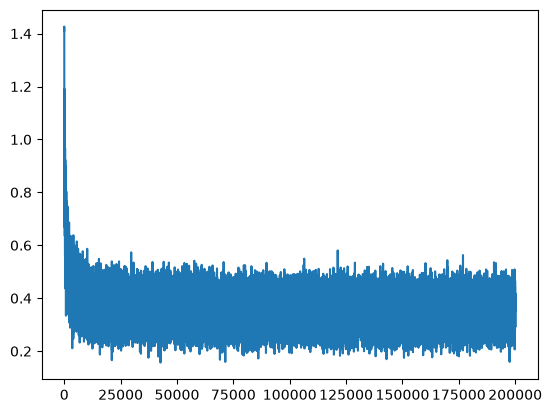

In [7]:
plt.plot(lossi)

In [8]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte),
    }[split]
    emb = C[x] # (N,block_size,n_embd)
    embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 2.2423930168151855
val 2.2655553817749023


In [9]:
# sample from the model
g = torch.Generator().manual_seed(214738323+10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ... 
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        # shift the context window and track the sample
        context = context[1:] + [ix]
        out.append(ix) 
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

abdily.
cana.
oladeyetne.
kynni.
coritta.
simly.
areem.
lavergie.
xairah.
zeyine.
aevaharkavin.
won.
mirkophie.
kayira.
caylen.
zar.
ema.
mami.
leey.
cine.


Lets find a way to make the initial guess to be much better, matters since gives us more time of optimizing the actual neural network

2 main issues

- initializtion of the W2 and b2 are too large of impacts at the beginning and need to be corrected --> fix by lowering their weights at the beginning

- when h is created at first we have a "hump" data set (due to values being in the flat part of the tanh) which with tanh derivative makes the actual data gradients a lot less impactful at the beginning (happens due to too extreme distribution of data) --> multiply the W1 and b1 by squashing values

In [10]:
# MLP revisited no more magic numbers

n_embd = 10 # the dimensionality of the char embedding vector
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(214738323) # reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd*block_size)**2 # gain / sqrt(fanin (input))
b1 = torch.randn(n_hidden,generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),generator=g) * 0.01 # want logits small
b2 = torch.randn(vocab_size, generator=g) * 0 # want no bias
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# note dont put W2 at zero 

12297


In [11]:
# same optimization as before

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,),generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch of X,Y

    # forward pass
    emb = C[Xb] # emb the chars into vectors
    embcat = emb.view(emb.shape[0],-1) # concentrate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer-pre-activation, want it to be gaussian (0 mean and 1 std at initialization)
    # bngain and bnbias are introductions for counteracting the gausian overtime
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias # batch normalization/ unit gaussian the layer 
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000 : 3.3183


  10000/ 200000 : 2.3195
  20000/ 200000 : 2.2720
  30000/ 200000 : 2.4575
  40000/ 200000 : 1.8477
  50000/ 200000 : 2.2525
  60000/ 200000 : 2.4007
  70000/ 200000 : 2.1962
  80000/ 200000 : 2.0850
  90000/ 200000 : 1.9358
 100000/ 200000 : 2.0400
 110000/ 200000 : 1.8417
 120000/ 200000 : 2.3589
 130000/ 200000 : 2.1621
 140000/ 200000 : 2.4273
 150000/ 200000 : 2.3503
 160000/ 200000 : 1.9159
 170000/ 200000 : 1.8677
 180000/ 200000 : 2.2534
 190000/ 200000 : 1.9673


In [12]:
# only use when breaking after first loop to see if h is on or off aim for ~ 1 or 2 white squares per row for extreme neurons

# plt.figure(figsize = (20,10))
# plt.imshow(h.abs() > 0.99, cmap='gray',interpolation='nearest')

In [13]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte),
    }[split]
    emb = C[x] # (N,block_size,n_embd)
    embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias # batch normalization/ unit gaussian the layer 
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 2.0911076068878174
val 2.126943826675415


our addition to the hpreact helps normalize batches and makes the model more consistent overall, it can be implemented to multiple layers

batch normalization leads to issues of coupling larger data sets which leads to the model being more inefficient, however since the regulization effect is super strong its hard to move away despite new methods being introduced

In [14]:
# calibrate the batch norm at the end of training

# benefit is only having to initialize once, downside its after the training

with torch.no_grad():
    # pass the training set trhough
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)
    

In [15]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte),
    }[split]
    emb = C[x] # (N,block_size,n_embd)
    embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias # batch normalization/ unit gaussian the layer 
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 2.0911076068878174
val 2.1271212100982666


In [16]:
# MLP revisited no more magic numbers

n_embd = 10 # the dimensionality of the char embedding vector
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(214738323) # reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd*block_size)**2 # gain / sqrt(fanin (input))
b1 = torch.randn(n_hidden,generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),generator=g) * 0.01 # want logits small
b2 = torch.randn(vocab_size, generator=g) * 0 # want no bias

# dont need gradients for these values, automatically updated without

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# note dont put W2 at zero 

12297


In [17]:
# same optimization as before

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,),generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch of X,Y

    # forward pass
    emb = C[Xb] # emb the chars into vectors
    embcat = emb.view(emb.shape[0],-1) # concentrate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer-pre-activation, want it to be gaussian (0 mean and 1 std at initialization)
    bnmeani = hpreact.mean(0,keepdim = True)
    bnstdi = hpreact.std(0,keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # batch normalization/ unit gaussian the layer 

    # like gradient descending but horribly simplified
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi 

    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000 : 3.3183
  10000/ 200000 : 2.3195
  20000/ 200000 : 2.2720
  30000/ 200000 : 2.4575
  40000/ 200000 : 1.8477
  50000/ 200000 : 2.2525
  60000/ 200000 : 2.4007
  70000/ 200000 : 2.1962
  80000/ 200000 : 2.0850
  90000/ 200000 : 1.9358
 100000/ 200000 : 2.0400
 110000/ 200000 : 1.8417
 120000/ 200000 : 2.3589
 130000/ 200000 : 2.1621
 140000/ 200000 : 2.4273
 150000/ 200000 : 2.3503
 160000/ 200000 : 1.9159
 170000/ 200000 : 1.8677
 180000/ 200000 : 2.2534
 190000/ 200000 : 1.9673


In [18]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte),
    }[split]
    emb = C[x] # (N,block_size,n_embd)
    embcat = emb.view(emb.shape[0],-1) # concat into (N,block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias # batch normalization/ unit gaussian the layer 
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')


train 2.0918917655944824
val 2.1282200813293457


After implementation of gaussian distributions on our initial guess and ways to slowly increment these new smoothening of batch normalizations we want to optimize by removing uneeded calculations 

Overview of batch normalization

- control the statistics of activations in the neural net 
- typical to be put after a linear or convolutional layer (trained using back propogation)
-  has 2 buffers that are trained on running means 
- uses means and std of batch to center and balance the valeus to be gausian, then offset and scaled by the bias and gain

## deep neural network pattern: 
#### Pattern Weight -> batchnormalization -> nonlinearity

In [49]:
# same optimization as before

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,),generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch of X,Y

    # forward pass
    emb = C[Xb] # emb the chars into vectors
    embcat = emb.view(emb.shape[0],-1) # concentrate the vectors
    hpreact = embcat @ W1 + b1

    # batch norm layer 

    bnmeani = hpreact.mean(0,keepdim = True)
    bnstdi = hpreact.std(0,keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # b1 replaced with bnbias 
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi 

    # non linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/ 200000 : 2.5945
  10000/ 200000 : 2.1203
  20000/ 200000 : 2.4237
  30000/ 200000 : 1.8091
  40000/ 200000 : 2.2424
  50000/ 200000 : 1.8063
  60000/ 200000 : 1.9583
  70000/ 200000 : 2.3922
  80000/ 200000 : 1.9535
  90000/ 200000 : 2.1273
 100000/ 200000 : 2.0210
 110000/ 200000 : 2.1026
 120000/ 200000 : 1.9834
 130000/ 200000 : 1.8130
 140000/ 200000 : 1.9653
 150000/ 200000 : 1.9864
 160000/ 200000 : 2.0745
 170000/ 200000 : 1.5937
 180000/ 200000 : 1.8365
 190000/ 200000 : 1.9856


In [1]:
# sample from the model
g = torch.Generator().manual_seed(-123)

for _ in range(25):

    out = []
    context = [0] * block_size # initialize with all ... 
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        # shift the context window and track the sample
        context = context[1:] + [ix]
        out.append(ix) 
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

NameError: name 'torch' is not defined